Kreuztabelle (Anzahl):
treatment   No  Yes
Age_group          
0-20        15   10
21-30      292  265
31-40      253  271
41-50       52   70
51-60        7   15
61-70        2    1
71+          0    1

Kreuztabelle (Prozent pro Altersgruppe):
treatment         No         Yes
Age_group                       
0-20       60.000000   40.000000
21-30      52.423698   47.576302
31-40      48.282443   51.717557
41-50      42.622951   57.377049
51-60      31.818182   68.181818
61-70      66.666667   33.333333
71+         0.000000  100.000000

Chi2-Statistik: 9.71
p-Wert: 0.1373
Freiheitsgrade: 6
Erwartete Häufigkeiten:
[[ 12.38038278  12.61961722]
 [275.83492823 281.16507177]
 [259.49282297 264.50717703]
 [ 60.41626794  61.58373206]
 [ 10.89473684  11.10526316]
 [  1.48564593   1.51435407]
 [  0.49521531   0.50478469]]
Cramér's V: 0.088


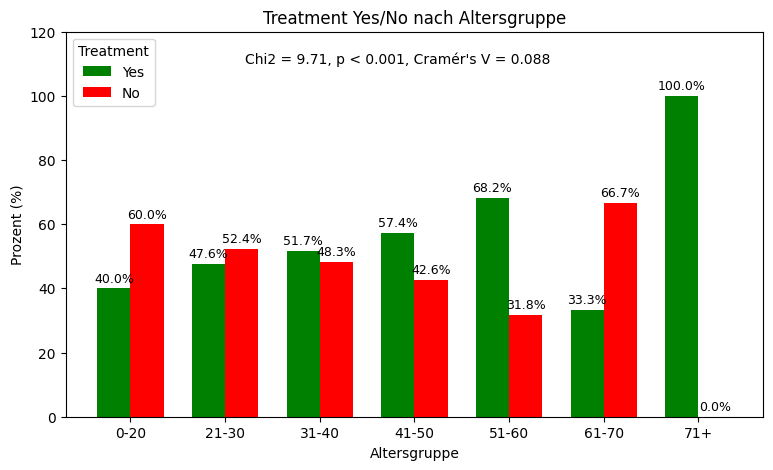

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# --- Daten einlesen ---
df = pd.read_csv("survey.csv")

# --- Treatment standardisieren ---
df['treatment'] = df['treatment'].str.strip().str.capitalize()  # Yes/No

# --- Altersgruppen erstellen ---
bins = [0, 20, 30, 40, 50, 60, 70, 100]  # Altersbereiche
labels = ['0-20','21-30','31-40','41-50','51-60','61-70','71+']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# --- Kreuztabelle Altersgruppe vs Treatment ---
ct_age = pd.crosstab(df['Age_group'], df['treatment'])
print("Kreuztabelle (Anzahl):")
print(ct_age)

ct_age_percent = pd.crosstab(df['Age_group'], df['treatment'], normalize='index') * 100
print("\nKreuztabelle (Prozent pro Altersgruppe):")
print(ct_age_percent)

# --- Chi-Quadrat-Test ---
chi2, p, dof, expected = chi2_contingency(ct_age)
print(f"\nChi2-Statistik: {chi2:.2f}")
print(f"p-Wert: {p:.4f}")
print(f"Freiheitsgrade: {dof}")
print("Erwartete Häufigkeiten:")
print(expected)

# --- Effektgröße (Cramér's V) ---
n = ct_age.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_age.shape)-1)))
print(f"Cramér's V: {cramers_v:.3f}")

# --- Balkendiagramm mit Prozentangaben, Yes links ---
fig, ax = plt.subplots(figsize=(9,5))
width = 0.35
age_groups = ct_age_percent.index.tolist()
treatments = ['Yes', 'No']  # Reihenfolge fixieren
x = range(len(age_groups))
colors = {"Yes": "green", "No": "red"}

for i, treatment in enumerate(treatments):
    heights = ct_age_percent[treatment].values
    ax.bar([p + i*width for p in x], heights, width=width, label=treatment, color=colors[treatment])
    for j, h in enumerate(heights):
        ax.text(j + i*width, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9)

# --- Signifikanzannotation mittig ---
x_mitte = (0 + len(age_groups) - 1) / 2
y_hoch = ct_age_percent.values.max() + 10
ax.text(x_mitte, y_hoch, 
        f"Chi2 = {chi2:.2f}, p < 0.001, Cramér's V = {cramers_v:.3f}", 
        fontsize=10, ha='center')

# Achsen, Titel, Legend
ax.set_xticks([p + width/2 for p in x])
ax.set_xticklabels(age_groups)
ax.set_ylabel("Prozent (%)")
ax.set_xlabel("Altersgruppe")
ax.set_title("Treatment Yes/No nach Altersgruppe")
ax.set_ylim(0, ct_age_percent.values.max() + 20)
ax.legend(title="Treatment")

plt.show()